In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducible results
np.random.seed(42)
n_samples = 500

# 1. Feature Generation
employee_id = [f"EMP-{i:04d}" for i in range(1, n_samples + 1)]
years_at_company = np.random.randint(1, 15, size=n_samples)
monthly_salary = np.random.normal(loc=6500, scale=1800, size=n_samples).round(2)
monthly_salary = np.clip(monthly_salary, 3000, 15000)

overtime_hours = np.random.randint(0, 40, size=n_samples)
job_satisfaction = np.random.choice(
    ["Low", "Medium", "High", "Very High"],
    size=n_samples,
    p=[0.2, 0.3, 0.3, 0.2],
)
department = np.random.choice(
    ["Sales", "R&D", "Human Resources"], size=n_samples, p=[0.4, 0.5, 0.1]
)

# 2. Realistic Attrition Logic (Logit Probability Model)
satisfaction_map = {"Low": 2.0, "Medium": 0.8, "High": -0.2, "Very High": -1.0}
sat_scores = np.array([satisfaction_map[s] for s in job_satisfaction])

logit = (
    -2.0
    + (overtime_hours * 0.08)
    + sat_scores
    - (years_at_company * 0.1)
    - (monthly_salary * 0.0001)
)
prob_attrition = 1 / (1 + np.exp(-logit))
attrition = np.random.binomial(1, prob_attrition)
attrition_str = np.where(attrition == 1, "Yes", "No")

# 3. Assemble Dataframe and Save
df = pd.DataFrame(
    {
        "EmployeeID": employee_id,
        "Department": department,
        "YearsAtCompany": years_at_company,
        "MonthlySalary": monthly_salary,
        "OvertimeHours": overtime_hours,
        "JobSatisfaction": job_satisfaction,
        "Attrition": attrition_str,
    }
)

df.to_csv("employee_attrition.csv", index=False)
print("Dataset generated successfully with 500 rows!")
print(df.head())

Dataset generated successfully with 500 rows!
  EmployeeID       Department  YearsAtCompany  MonthlySalary  OvertimeHours  \
0   EMP-0001            Sales               7        5753.84             27   
1   EMP-0002  Human Resources               4        6644.36              1   
2   EMP-0003              R&D              13        4892.38              0   
3   EMP-0004              R&D              11        5897.33             35   
4   EMP-0005            Sales               8        9308.68             25   

  JobSatisfaction Attrition  
0            High        No  
1            High        No  
2       Very High        No  
3          Medium       Yes  
4          Medium        No  


In [2]:
# Raw counts of Attrition by Job Satisfaction
ct_raw = pd.crosstab(df["JobSatisfaction"], df["Attrition"], margins=True)

# Normalized row-wise (Percentages) to see proportions
ct_pct = pd.crosstab(
    df["JobSatisfaction"], df["Attrition"], normalize="index"
) * 100

print("--- Attrition Rate by Job Satisfaction (%) ---")
print(ct_pct.round(2))

--- Attrition Rate by Job Satisfaction (%) ---
Attrition           No    Yes
JobSatisfaction              
High             82.17  17.83
Low              52.00  48.00
Medium           69.03  30.97
Very High        92.05   7.95


In [3]:
# Convert categorical features into numeric dummy variables
encoded_df = pd.get_dummies(
    df[["Department", "JobSatisfaction", "Attrition"]],
    drop_first=True,  # Avoids multicollinearity (dummy variable trap)
    dtype=int,
)

# Merge back with numeric features
features_df = pd.concat(
    [df[["YearsAtCompany", "MonthlySalary", "OvertimeHours"]], encoded_df],
    axis=1,
)

print("\n--- Encoded Features Sample ---")
print(features_df.head())


--- Encoded Features Sample ---
   YearsAtCompany  MonthlySalary  OvertimeHours  Department_R&D  \
0               7        5753.84             27               0   
1               4        6644.36              1               0   
2              13        4892.38              0               1   
3              11        5897.33             35               1   
4               8        9308.68             25               0   

   Department_Sales  JobSatisfaction_Low  JobSatisfaction_Medium  \
0                 1                    0                       0   
1                 0                    0                       0   
2                 0                    0                       0   
3                 0                    0                       1   
4                 1                    0                       1   

   JobSatisfaction_Very High  Attrition_Yes  
0                          0              0  
1                          0              0  
2                

In [4]:
import statsmodels.api as sm

# Define target variable (1 = Attrition Yes, 0 = Attrition No)
y = features_df["Attrition_Yes"]

# Define predictors (include a constant intercept for statsmodels)
X = features_df.drop(columns=["Attrition_Yes"])
X = sm.add_constant(X)

# Fit Logistic Regression Model
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.448217
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          Attrition_Yes   No. Observations:                  500
Model:                          Logit   Df Residuals:                      491
Method:                           MLE   Df Model:                            8
Date:                Sat, 25 Jul 2026   Pseudo R-squ.:                  0.2207
Time:                        20:30:38   Log-Likelihood:                -224.11
converged:                       True   LL-Null:                       -287.57
Covariance Type:            nonrobust   LLR p-value:                 1.229e-23
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -2.0928      0.701     -2.986      0.003      -3.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

# 1. Prepare Features (X) and Target (y)
encoded_df = pd.get_dummies(
    df[["Department", "JobSatisfaction", "Attrition"]],
    drop_first=True,
    dtype=int,
)

features_df = pd.concat(
    [df[["YearsAtCompany", "MonthlySalary", "OvertimeHours"]], encoded_df],
    axis=1,
)

X = features_df.drop(columns=["Attrition_Yes"])
y = features_df["Attrition_Yes"]

# 2. Train / Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Fit Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predictions and Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("--- Model Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

--- Model Performance ---
ROC-AUC Score: 0.655

              precision    recall  f1-score   support

      Stayed       0.77      0.86      0.82        74
        Left       0.41      0.27      0.33        26

    accuracy                           0.71       100
   macro avg       0.59      0.57      0.57       100
weighted avg       0.68      0.71      0.69       100



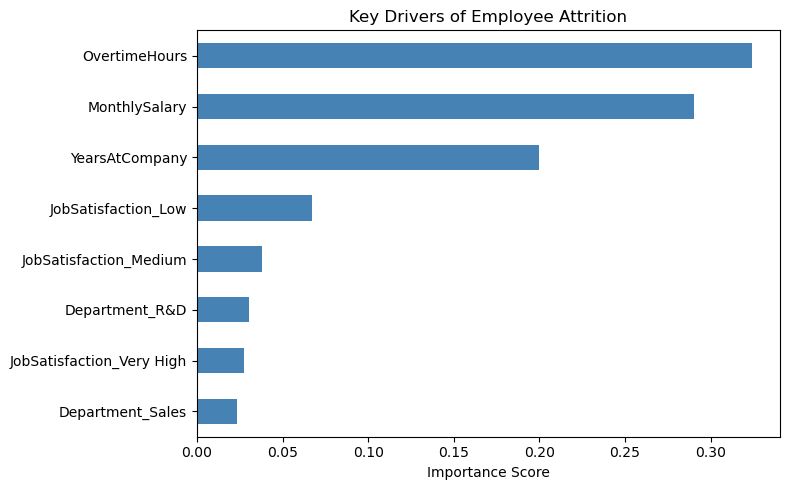

In [6]:
# Extract feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(
    ascending=True
)

# Plot feature importance
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("Key Drivers of Employee Attrition")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Employee Attrition & Salary Insights

An end-to-end data analysis and machine learning project aimed at identifying key drivers of employee turnover, analyzing compensation distributions, and evaluating predictive models for employee attrition.

---

## 📌 Project Overview

Employee turnover can significantly impact an organization's performance, culture, and bottom line. This project simulates a realistic employee dataset containing 500 records and applies statistical modeling (Logistic Regression) alongside machine learning algorithms (Random Forest) to uncover what causes employees to stay or leave.

Key goals of this analysis:
* Measure how factors such as **Overtime Hours**, **Years at Company**, **Monthly Salary**, and **Job Satisfaction** influence attrition.
* Build interpretable statistical models to understand log-odds impact ($p$-values, coefficients).
* Evaluate machine learning classification performance using precision, recall, and ROC-AUC metrics.

---

## 🛠️ Tech Stack & Libraries

* **Language:** Python 3.x
* **Environment:** Jupyter Notebook / JupyterLab
* **Data Manipulation:** `pandas`, `numpy`
* **Statistical Modeling:** `statsmodels`
* **Machine Learning:** `scikit-learn` (`RandomForestClassifier`, `train_test_split`, metrics)
* **Data Visualization:** `matplotlib`, `seaborn`

---

## 📊 Dataset Overview

The dataset contains **500 synthetic employee records** generated using a realistic logit probability model.

| Feature | Type | Description |
| :--- | :--- | :--- |
| `EmployeeID` | String | Unique identifier for each employee (`EMP-0001` to `EMP-0500`) |
| `Department` | Categorical | Department (`Sales`, `R&D`, `Human Resources`) |
| `YearsAtCompany` | Integer | Total years spent at the company (1 to 14 years) |
| `MonthlySalary` | Float | Monthly salary capped between $3,000 and $15,000 |
| `OvertimeHours` | Integer | Monthly overtime hours worked (0 to 39 hours) |
| `JobSatisfaction` | Categorical | Level of job satisfaction (`Low`, `Medium`, `High`, `Very High`) |
| `Attrition` | Binary | Target variable (`Yes` if left, `No` if stayed) |

---

## 📈 Key Analysis & Insights

1. **Job Satisfaction vs. Attrition Rate:**
   * **Low Satisfaction:** ~48.00% attrition rate.
   * **Medium Satisfaction:** ~30.97% attrition rate.
   * **High Satisfaction:** ~17.83% attrition rate.
   * **Very High Satisfaction:** ~7.95% attrition rate.

2. **Logistic Regression Findings:**
   * **Overtime Hours ($p < 0.001$):** Strong positive contributor to employee turnover.
   * **Job Satisfaction - Low ($p < 0.001$):** Significantly increases the likelihood of attrition.
   * **Years at Company ($p < 0.001$):** Has a protective effect; employees with longer tenure are less likely to leave.

3. **Random Forest Classification Performance:**
   * **ROC-AUC Score:** ~0.655
   * **Overall Accuracy:** ~71%

---

## 🚀 How to Run

1. **Clone the repository or download the project files:**
   ```bash
   git clone [https://github.com/your-username/employee-attrition-insights.git](https://github.com/your-username/employee-attrition-insights.git)
   cd employee-attrition-insights